In [2]:
import os
import torch
import numpy
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

# Ensure working directory is project root when running inside notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Ensure models directory exists
os.makedirs("models", exist_ok=True)

# Select computing device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working Directory: {os.getcwd()}")
print(f"Using device: {device}")

Working Directory: E:\AI-ML\plant_disease_detection
Using device: cpu


In [3]:
def get_data_loaders(data_dir="data/raw", batch_size=32, train_split=0.8, image_size=(224, 224)):
    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    num_classes = len(full_dataset.classes)

    train_size = int(train_split * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    val_dataset.dataset.transform = val_transform

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, num_classes, full_dataset.classes

In [4]:
def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def plot_training_history(train_losses, val_losses, train_accs, val_accs, save_path="models/training_history.png"):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-o', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'b-o', label='Training Accuracy')
    plt.plot(epochs, val_accs, 'r-o', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

def predict_image(image_path, model, class_names, device, image_size=(224, 224)):
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    tensor_img = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(tensor_img)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_prob, top_class = torch.topk(probabilities, 1)

    predicted_label = class_names[top_class.item()]
    confidence = top_prob.item() * 100

    return predicted_label, confidence

Loading data...


Epoch 1/5 [Train]:   0%|          | 0/894 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 2/5 | Train Loss: 0.2591, Train Acc: 92.58% | Val Loss: 0.2038, Val Acc: 93.76%


...

Epoch 4/5 [Val]:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.1825, Train Acc: 94.45% | Val Loss: 0.1876, Val Acc: 93.91%


Epoch 5/5 [Train]:   0%|          | 0/894 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 0.1649, Train Acc: 94.67% | Val Loss: 0.1714, Val Acc: 94.35%

Model successfully saved to: models/plant_disease_resnet18.pth


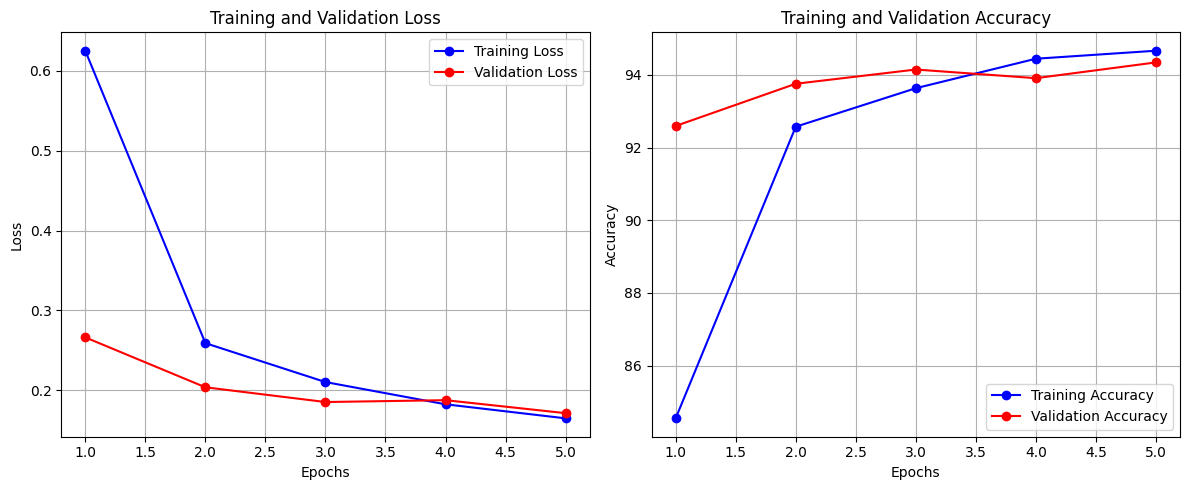

In [5]:
import numpy
def train_and_save_model(epochs=5, batch_size=32, lr=0.001):
    print("Loading data...")
    train_loader, val_loader, num_classes, class_names = get_data_loaders(batch_size=batch_size)
    
    model = build_model(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for images, labels in train_loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            train_loop.set_postfix(loss=loss.item())

        epoch_loss = running_loss / total
        epoch_acc = correct / total * 100

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for images, labels in val_loop:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        valid_loss = val_loss / val_total
        valid_acc = val_correct / val_total * 100

        train_losses.append(epoch_loss)
        val_losses.append(valid_loss)
        train_accs.append(epoch_acc)
        val_accs.append(valid_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | Val Loss: {valid_loss:.4f}, Val Acc: {valid_acc:.2f}%")

    # Local Saving
    save_path = "models/plant_disease_resnet18.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel successfully saved to: {save_path}")

    plot_training_history(train_losses, val_losses, train_accs, val_accs)
    
    return model, class_names

# Run Training Loop
trained_model, dataset_classes = train_and_save_model(epochs=5, batch_size=32)

In [6]:
# Test model inference locally
test_image_path = "data/raw/Tomato___Bacterial_spot/01a3cf3f-94c1-4eb9-9d3c-94113e478ee2___GCREC_Bact.Sp 3396.JPG"

if os.path.exists(test_image_path):
    label, conf = predict_image(test_image_path, trained_model, dataset_classes, device)
    print(f"Prediction: {label}")
    print(f"Confidence: {conf:.2f}%")
    
    img = Image.open(test_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label} ({conf:.1f}%)")
    plt.show()
else:
    print(f"Please provide a valid image path. Image not found at: {test_image_path}")

Please provide a valid image path. Image not found at: data/raw/Tomato___Bacterial_spot/01a3cf3f-94c1-4eb9-9d3c-94113e478ee2___GCREC_Bact.Sp 3396.JPG
